In [10]:
%load_ext autoreload

%autoreload 2
import numpy as np
import corner, sys
import getdist
from getdist import plots, MCSamples
%matplotlib inline
import matplotlib.pyplot as plt
sys.path.append('../../modules/')
import numpy as np
#plt.switch_backend("Qt5Agg")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
names = ['1', '2', '3', '4', '5', '6']
labels = [r'\ln \lambda_0', r'\mu_z', r'\mu_m', r'\sigma_{\ln \lambda, 0}', r'\sigma_z', r'\sigma_m']
settings={'mult_bias_correction_order':0,'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

In [12]:
params_fid=[3.345953364933381,
 0.06378674560099672,
 2.2274595352385975,
 0.5634900828247924,
 -0.04529427946062734,
 0.09764409931399064]

In [13]:
markers={f'{i+1}':params_fid[i] for i in range(len(params_fid))}

In [14]:
markers

{'1': 3.345953364933381,
 '2': 0.06378674560099672,
 '3': 2.2274595352385975,
 '4': 0.5634900828247924,
 '5': -0.04529427946062734,
 '6': 0.09764409931399064}

In [18]:
n_cut=19000
name='1-halo=nfw+c-M=Duffy08_rmin=1.0-rmax=3.5_photoz=Truez_hmf=Despali16'
t = np.load(f'../chains/MxN/MCMC_fit_m-r_MxN_{name}.pkl', allow_pickle = True)
MxNDuffy08 = MCSamples(samples=t['flat_chains'][n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label='Duffy et al. 2008')
name='1-halo=nfw+c-M=Prada12_rmin=1.0-rmax=3.5_photoz=Truez_hmf=Despali16'
t = np.load(f'../chains/MxN/MCMC_fit_m-r_MxN_{name}.pkl', allow_pickle = True)
MxNPrada12 = MCSamples(samples=t['flat_chains'][n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label='Prada et al. 2012')
name='1-halo=nfw+c-M=Bhattacharya13_rmin=1.0-rmax=3.5_photoz=Truez_hmf=Despali16'
t = np.load(f'../chains/MxN/MCMC_fit_m-r_MxN_{name}.pkl', allow_pickle = True)
MxNBhattacharya13 = MCSamples(samples=t['flat_chains'][n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label='Bhattacharya et al. 2013')
name='1-halo=nfw+c-M=Diemer15_rmin=1.0-rmax=3.5_photoz=Truez_hmf=Despali16'
t = np.load(f'../chains/MxN/MCMC_fit_m-r_MxN_{name}.pkl', allow_pickle = True)
MxNDiemer15 = MCSamples(samples=t['flat_chains'][n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label='Diemer & Kravtsov 2014')
name='1-halo=nfw+c-M=None_rmin=1.0-rmax=3.5_photoz=Truez_hmf=Despali16'
t = np.load(f'../chains/MxN/MCMC_fit_m-r_MxN_{name}.pkl', allow_pickle = True)
MxNnone = MCSamples(samples=t['flat_chains'][n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label='free concentration')

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


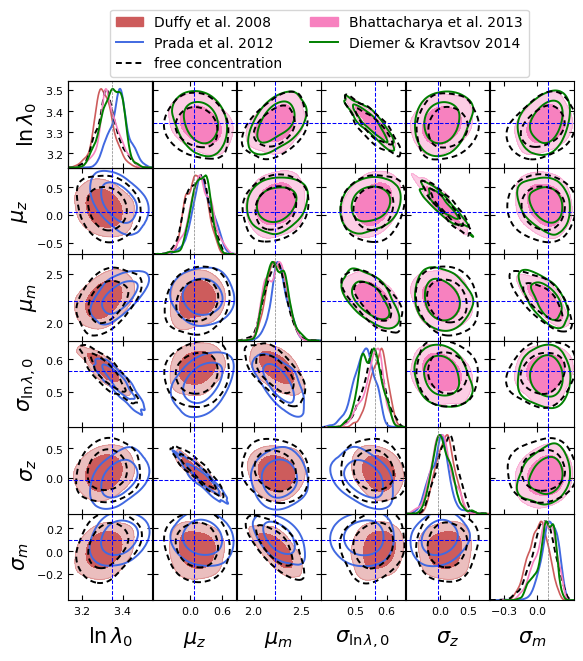

In [20]:
g = plots.get_subplot_plotter(subplot_size=1.)
g.settings.lab_fontsize = 20
g.settings.legend_fontsize = 15
g.settings.figure_legend_ncol = 2
g.settings.axes_fontsize = 13
range_ = {'1':[2.5,4], '2':[-2,2], '3':[1,4], '4':[0.1,1.2],'5':[-1.5,1.5], '6':[-0.5,0.5], }
g.triangle_plot(
                [MxNDuffy08,MxNPrada12,MxNnone], 
                filled=[True, False, False, False, False], 
                contour_colors=['indianred','royalblue','k'],
                contour_ls=['-','-','--'],
                contour_lws=[1.2,1.4,1.4],
                legend_fontsize = 10,
                #param_limits=range_,
                params=['1','2','3','4','5','6'],markers=markers,
                fine_bins = 1,  marker_args = marker_args, 

   upper_roots = [MxNBhattacharya13,MxNDiemer15,MxNnone],
                upper_kwargs = { 'filled':[True, False, False, False, False],
                                'shaded':False, 
                                'contour_lws':[1.2,1.4,1.4],
                    'contour_colors':['#f781bf','g','k'], 
                                'contour_ls':['-','-','--']}
)
plt.savefig(f'../fig_erratum/mcmc_scaling_relation_impact_cMr_masses.png', dpi = 300,bbox_inches='tight',)